# Hate Speech Detection Model - NLP

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud, STOPWORDS
import neattext as nfx
import re
import joblib
from collections import Counter

In [2]:
df=pd.read_csv('HateSpeechDataset.csv')

### EDA - Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440906 entries, 0 to 440905
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Content      440906 non-null  object
 1   Label        440906 non-null  object
 2   Content_int  440906 non-null  object
dtypes: object(3)
memory usage: 10.1+ MB


In [4]:
df.head()

,Content,Label,Content_int
0,denial of normal the con be asked to comment o...,1,"[146715, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,..."
1,just by being able to tweet this insufferable ...,1,"[146715, 14, 15, 16, 17, 7, 18, 19, 20, 21, 22..."
2,that is retarded you too cute to be single tha...,1,"[146715, 28, 29, 30, 26, 31, 32, 7, 5, 33, 28,..."
3,thought of a real badass mongol style declarat...,1,"[146715, 35, 1, 24, 36, 37, 38, 39, 40, 1, 41,..."
4,afro american basho,1,"[146715, 46, 47, 48, 146714]"


In [5]:
df.tail()

,Content,Label,Content_int
440901,crash another movie from left field i have to ...,0,"[146715, 1780, 649, 1673, 347, 701, 1702, 80, ..."
440902,i why do not you debate first before starting ...,0,"[146715, 80, 186, 340, 76, 26, 6407, 566, 2608..."
440903,removal of i reverted the removal of the above...,0,"[146715, 18731, 1, 80, 48182, 3, 18731, 1, 3, ..."
440904,i have unblocked you eddie as i discussed on u...,0,"[146715, 80, 87, 20515, 26, 10684, 273, 80, 95..."
440905,you have the ability to delete that revision a...,0,"[146715, 26, 87, 3, 12795, 7, 3358, 28, 3938, ..."


In [6]:
print(df["Label"].unique())

['1' '0' 'Label']


In [7]:
df.isnull().sum()

Content        0
Label          0
Content_int    0
dtype: int64

In [8]:
df = df[df["Label"] != "Label"]

In [9]:
df["Label"] = df["Label"].astype(int)

In [10]:
df["Content"] = df["Content"].fillna("").astype(str)

In [11]:
df['Content'] = df['Content'].str.lower()# Metni küçük harfe çevirir
df['Content'] = df['Content'].str.replace(r'<.*?>', '', regex=True)# HTML tagleri kaldır
df['Content'] = df['Content'].str.replace(r'[^\w\s]', '', regex=True)# Noktalama işaretlerini kaldır
df['Content'] = df['Content'].str.replace(r'\d+', '', regex=True)# Sayıları kaldır
df['Content'] = df['Content'].str.replace(r'\n', '', regex=True)# Satır sonlarını ve enterları kaldır
df['Content'] = df['Content'].str.replace(r'\r', '', regex=True)

In [12]:
def ekkok(Content): 
    words=TextBlob(Content).words 
    return [word.lemmatize() for word in words] 

In [13]:
vect=CountVectorizer(analyzer=ekkok, stop_words='english', ngram_range=(1,2))

### WordCloud

In [14]:
all_words = " ".join(df["Content"]).split()
word_counts = Counter(all_words)
word_counts.most_common(20)

[('the', 778242),
 ('to', 496638),
 ('a', 460630),
 ('i', 418021),
 ('you', 388623),
 ('and', 356582),
 ('is', 356319),
 ('of', 349613),
 ('it', 260312),
 ('that', 259826),
 ('not', 254668),
 ('in', 230676),
 ('for', 174272),
 ('are', 170484),
 ('this', 161963),
 ('on', 150761),
 ('what', 143720),
 ('have', 141981),
 ('be', 140813),
 ('as', 118145)]

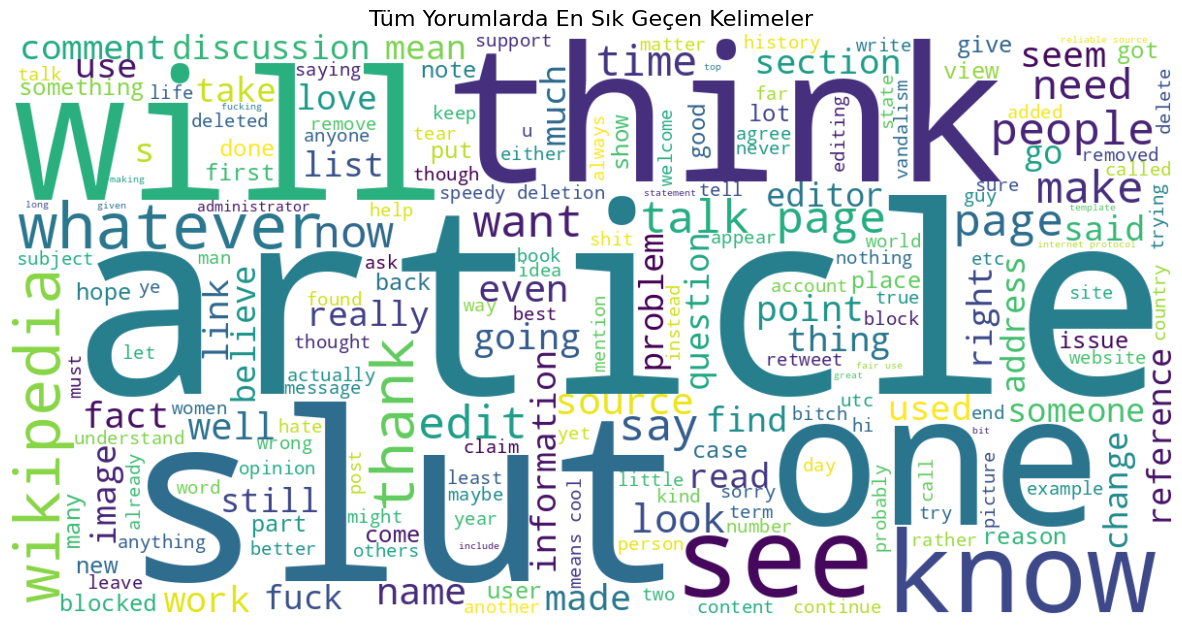

In [15]:
Content = " ".join(df['Content'])
stopwords = set(STOPWORDS)
wc = WordCloud(stopwords=stopwords, background_color='white', width=1200, height=600).generate(Content)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Tüm Yorumlarda En Sık Geçen Kelimeler', fontsize=16)
plt.show()

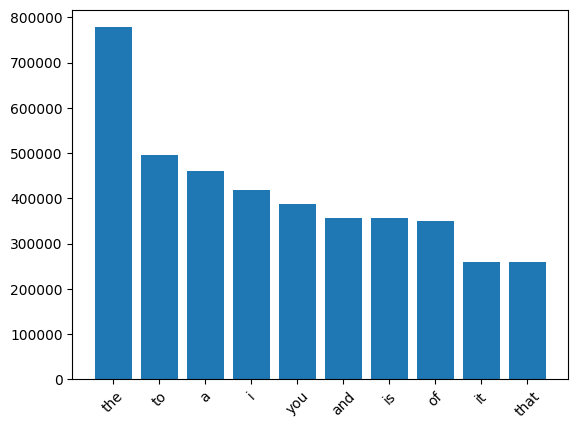

In [16]:
import matplotlib.pyplot as plt
common_words = word_counts.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.show()

In [17]:
hate_text = " ".join(df[df["Label"] == 1]["Content"])
non_hate_text = " ".join(df[df["Label"] == 0]["Content"])

In [18]:
hate_wc = WordCloud(background_color="white").generate(hate_text)
non_hate_wc = WordCloud(background_color="white").generate(non_hate_text)

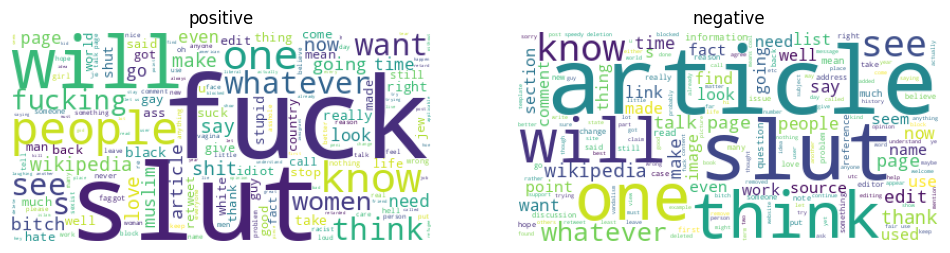

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(hate_wc)
plt.axis("off")
plt.title("positive")

plt.subplot(1,2,2)
plt.imshow(non_hate_wc)
plt.axis("off")
plt.title("negative")

plt.show()

### Modelling and Testing

In [20]:
x = df["Content"]
y = df["Label"]

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
vectorizer = TfidfVectorizer(max_features=1000)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [23]:
model = LogisticRegression()
model.fit(x_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
y_pred = model.predict(x_test_vec)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8433204808346564
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     72346
           1       0.63      0.31      0.42     15834

    accuracy                           0.84     88180
   macro avg       0.75      0.64      0.66     88180
weighted avg       0.82      0.84      0.82     88180



In [26]:
joblib.dump(model, 'HateSpeech.pkl')

['HateSpeech.pkl']

In [27]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.model_selection import train_test_split


def algo_test(x, y):
    """
    x: text data (Series / list)
    y: Labels (1D array)
    """

    # Label düzeltme
    y = np.array(y).ravel()

    # train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    # modeller
    models = {
        "BernoulliNB": BernoulliNB(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "DecisionTree": DecisionTreeClassifier(),
        "RandomForest": RandomForestClassifier(random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "KNeighbors": KNeighborsClassifier(),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "MultinomialNB": MultinomialNB()
    }

    results = []

    print("🚀 Model karşılaştırma başlıyor...\n")

    for name, model in models.items():
        print(f"➡ {name} eğitiliyor...")

        pipe = Pipeline([
            ("tfidf", TfidfVectorizer()),
            ("clf", model)
        ])

        pipe.fit(x_train, y_train)
        preds = pipe.predict(x_test)

        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds, average="weighted", zero_division=0)
        rec = recall_score(y_test, preds, average="weighted", zero_division=0)
        f1 = f1_score(y_test, preds, average="weighted", zero_division=0)

        print("Confusion Matrix:")
        print(confusion_matrix(y_test, preds))
        print("-" * 50)

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Pipeline": pipe
        })

    results_df = pd.DataFrame(results)
    results_df.sort_values("F1", ascending=False, inplace=True)

    best_model = results_df.iloc[0]["Pipeline"]

    print("\n🏆 EN İYİ MODEL:", results_df.iloc[0]["Model"])

    best_preds = best_model.predict(x_test)

    print("\n📊 BEST MODEL REPORT")
    print(confusion_matrix(y_test, best_preds))
    print(classification_report(y_test, best_preds))

    return results_df.drop(columns=["Pipeline"])

In [28]:
algo_test(x, y)

🚀 Model karşılaştırma başlıyor...

➡ BernoulliNB eğitiliyor...
Confusion Matrix:
[[40913 31406]
 [ 2547 13314]]
--------------------------------------------------
➡ LogisticRegression eğitiliyor...
Confusion Matrix:
[[69511  2808]
 [ 8285  7576]]
--------------------------------------------------
➡ DecisionTree eğitiliyor...
Confusion Matrix:
[[66171  6148]
 [ 7152  8709]]
--------------------------------------------------
➡ RandomForest eğitiliyor...
Confusion Matrix:
[[70790  1529]
 [ 9626  6235]]
--------------------------------------------------
➡ GradientBoosting eğitiliyor...
Confusion Matrix:
[[71592   727]
 [13354  2507]]
--------------------------------------------------
➡ KNeighbors eğitiliyor...
Confusion Matrix:
[[70558  1761]
 [12342  3519]]
--------------------------------------------------
➡ AdaBoost eğitiliyor...
Confusion Matrix:
[[71240  1079]
 [14550  1311]]
--------------------------------------------------
➡ MultinomialNB eğitiliyor...
Confusion Matrix:
[[70926  13

,Model,Accuracy,Precision,Recall,F1
1,LogisticRegression,0.874200,0.864019,0.874200,0.863369
3,RandomForest,0.873497,0.866406,0.873497,0.855172
2,DecisionTree,0.849172,0.845571,0.849172,0.847227
7,MultinomialNB,0.847857,0.833228,0.847857,0.814726
5,KNeighbors,0.840066,0.817910,0.840066,0.805494
4,GradientBoosting,0.840315,0.830636,0.840315,0.793928
6,AdaBoost,0.822760,0.779701,0.822760,0.764901
0,BernoulliNB,0.614958,0.825616,0.614958,0.658682
